In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_2'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_klow'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_khigh'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_ksuper_high'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_ksuper_low'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/red_ksuper_low_1E8'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/red_ksuper_low_2'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/.DS_Store')]

In [3]:
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)
scenario_name = "red_ksuper_low_2"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
df = pd.read_csv(os.path.join(post_path, 'parameters_best_0.csv'))
range_real = [0, 1, 3, 4, 6, 7, 9, 10, 11, 12, 13]
range_alive = [1, 4, 9, 10, 11, 12, 13]
range_dead = [0, 3, 6, 7]

In [4]:
df_dead_list = []
for id in range_dead:
    df = pd.read_csv(os.path.join(post_path, f'parameters_best_{id}.csv')).sort_values(by=[f't{id}'])
    df.reset_index(inplace=True)
    df_dead_list.append(df)
df_alive = pd.read_csv(os.path.join(post_path, f'parameters_best_mean_alive.csv')).sort_values(by=['alive_mean'])
df_alive.reset_index(inplace=True)
variables = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
             'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0',
             'jackson_root_beta', 'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

In [5]:
dfd0 = df_dead_list[3][variables][0:60000:4]
dfd0['alive'] = 0
dfd1 = df_dead_list[0][variables][0:60000:4]
dfd1['alive'] = 0
# dfd2 = df_dead_list[2][variables][0:60000:40]
# dfd2['alive'] = 0
# dfd3 = df_dead_list[3][variables][0:60000:40]
# dfd3['alive'] = 0
dfa = df_alive[variables][0:60000:2]
dfa['alive'] = 1
dfcs = pd.concat([dfd0, dfa], axis=0)
dfc = dfcs.drop(['alive'], axis=1)
dfc = (dfc - dfc.mean()) / dfc.std()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [7]:
X_train, X_test, y_train, y_test = train_test_split(dfc, dfcs['alive'], test_size=0.2, random_state=42)

In [8]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    random_state=2909,)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=3, random_state=2909)

In [9]:
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.9970016286812559
0.9980989529950792


In [10]:
import shap
shap.initjs()

In [11]:
X_train

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
47944,0.663843,0.684841,0.850018,1.395069,0.781364,0.885289,0.261599,-0.355458,1.104989,-0.485002,0.856075,0.006971,0.173838,-0.819461,0.651637,0.887677,-0.485014
19828,-0.564428,1.195962,1.127796,0.453031,-0.049936,-0.715406,0.103814,0.342072,1.561611,0.951865,0.854166,1.615996,0.380316,-0.653174,0.222890,0.901576,0.195586
12124,-0.840607,1.004178,-1.415786,-0.542081,1.168930,0.457123,0.023138,1.589861,-0.667110,-1.639564,1.469392,-1.124867,-1.204537,-0.102188,0.141052,0.321481,2.107261
38528,-0.773388,-0.638781,-1.338987,0.884949,0.254644,-0.238217,-0.889648,1.854751,-1.612386,-1.002823,-0.899021,-0.529412,-1.433735,-1.159775,1.257788,-0.519000,1.217349
33972,0.403295,-1.902237,-0.263395,-1.791677,1.089351,-0.608876,1.484436,-0.618920,-1.314122,0.232044,0.396942,-1.146424,0.846953,1.681888,1.126092,0.725468,0.628243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25060,-1.241146,-0.189920,-1.224702,1.269608,0.798018,1.274621,0.928480,2.025937,-0.684861,-0.459848,0.485966,0.366760,-1.201091,-0.943404,-1.895768,-1.536709,1.095807
45136,-0.245602,1.502144,-1.292674,1.402491,0.189517,-0.319000,0.940086,-0.816939,-0.945083,-0.792545,0.718849,0.587021,-1.776733,0.431880,-0.862148,-1.539814,0.359153
50716,-0.802299,-0.612023,0.726150,0.461615,-0.238458,-0.169681,-0.052553,-1.163574,-1.078087,0.682822,-0.159392,1.180009,0.334048,0.867652,0.988690,0.520740,-0.777392
3440,0.127555,-2.040289,-1.219593,1.345631,-0.581358,-0.641050,-1.471966,-1.271579,-1.263240,-2.109327,-0.634451,-0.445064,-1.871844,-0.949993,0.765848,-2.490923,-0.748756


In [12]:
explainer = shap.Explainer(rf)
shap_values = explainer(X_train)

In [13]:
np.shape(shap_values.values)

(30720, 17)

In [93]:
shap.plots.force(shap_values[0:100])

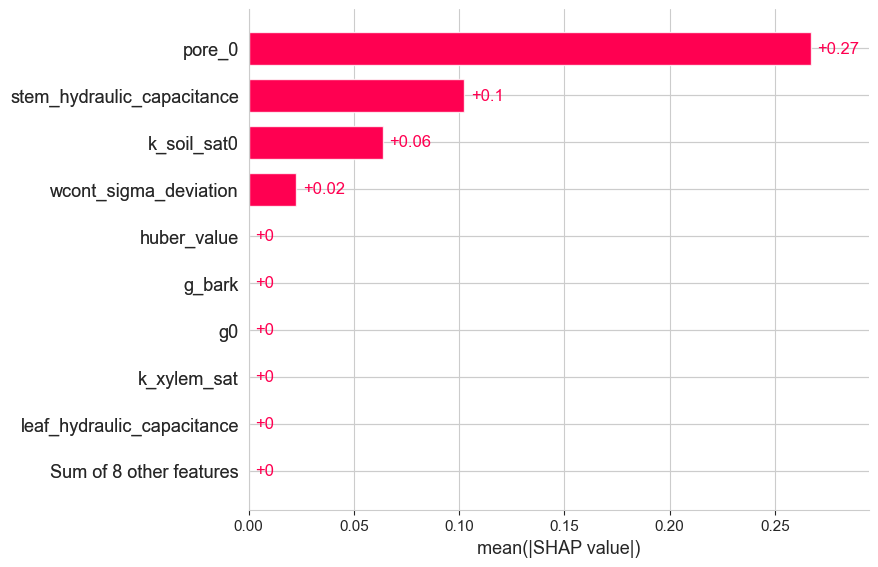

In [94]:
shap.plots.bar(shap_values)

In [106]:
import matplotlib.pyplot as plt

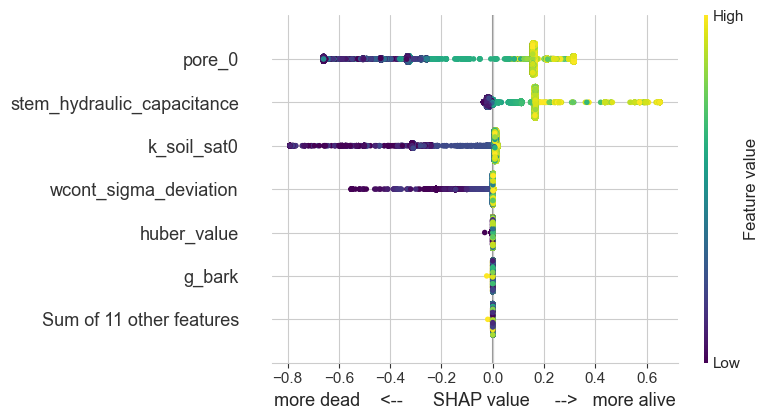

In [124]:

#plt.subplot(1,1,1)
#plt.xlabel("A")
shap.plots.beeswarm(shap_values, color="viridis", max_display=7, show = False)
ax = plt.gca()
ax.set_xlabel("more dead    <--      SHAP value     -->   more alive")
plt.tight_layout()
plt.savefig(os.path.join("plt", 'shap_values.png'), dpi = 300)
plt.show()

#ax.set_xlabel('Wichtigste Merkmale', fontsize=14)

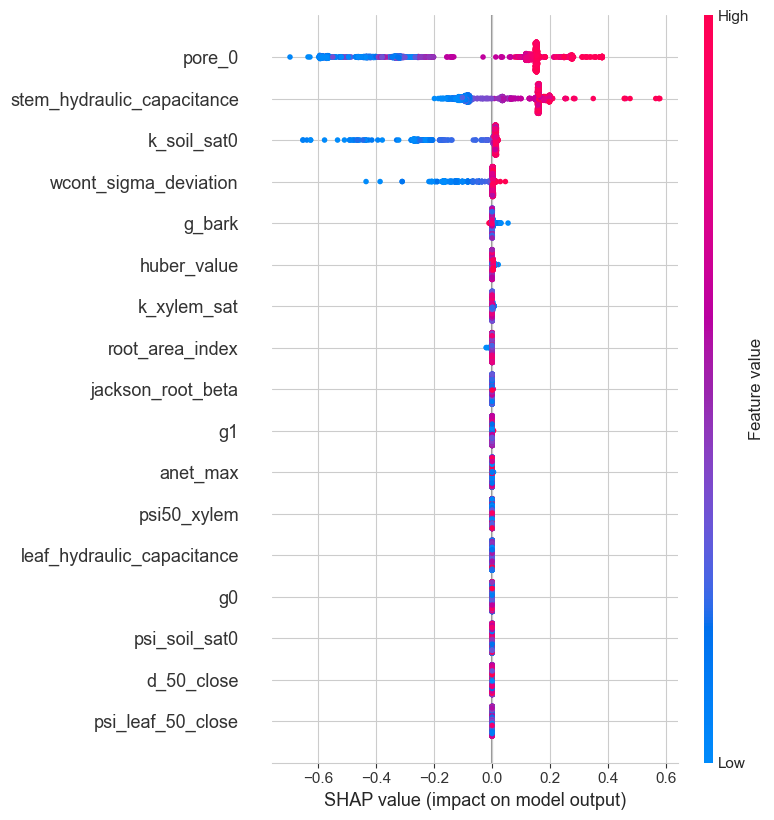

In [76]:
explainer2 = shap.KernelExplainer(rf.predict, shap.kmeans(X_train, 40))
shap_values2 = explainer.shap_values(X_test)
shap.summary_plot(shap_values2, X_test, feature_names=X_test.columns)

In [19]:
from sklearn.svm import LinearSVC

In [20]:
clf = LinearSVC(random_state=42)
clf.fit(X_train, y_train)

LinearSVC(random_state=42)

In [21]:
clf.score(X_test, y_test)

1.0

In [22]:
clf.predict(X_test[0])

KeyError: 0

In [23]:
explainer = shap.KernelExplainer(clf.predict, shap.kmeans(X_train, 10))

In [24]:
shap_values = explainer.shap_values(X_test)

  0%|          | 0/1200 [00:00<?, ?it/s]

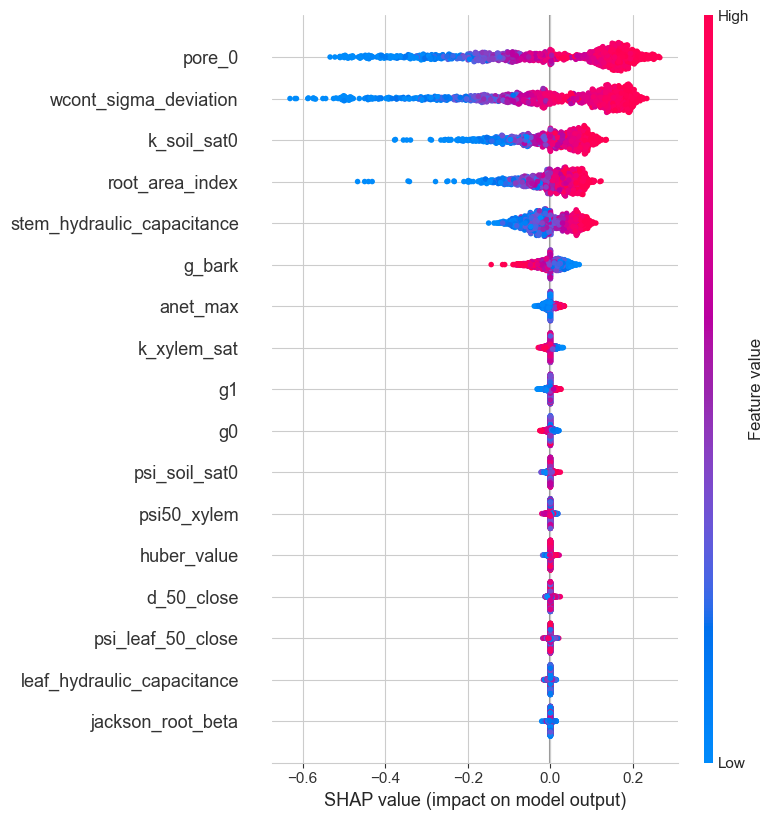

In [25]:
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)